# Q-Learning para Recomendación de Recetas con Sellos Nutricionales



## 1. Carga de Datos

In [ ]:
import kagglehub
local_dataset_path = kagglehub.dataset_download('irkaal/foodcom-recipes-and-reviews')

Using Colab cache for faster access to the 'foodcom-recipes-and-reviews' dataset.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from collections import defaultdict
from tqdm.auto import tqdm

In [ ]:
full_reviews_path = os.path.join(local_dataset_path, 'reviews.csv')
reviews = pd.read_csv(full_reviews_path)
print(f"Reviews cargadas: {len(reviews)}")

Reviews cargadas: 1401982


In [ ]:
!pip install gdown -q

file_id = '1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG'
output_filename = 'recipes_final_consolidado.csv'
!gdown --id {file_id} -O {output_filename}

recipes = pd.read_csv(output_filename)
recipes['ExtractedServingSize'] = recipes['ExtractedServingSize'].str.extract(r'\((.*?)\)').astype(float)
print(f"Recetas cargadas: {len(recipes)}")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG
From (redirected): https://drive.google.com/uc?id=1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG&confirm=t&uuid=6ac74ce8-5498-4586-a7ad-2dc6d09a4254
To: /content/recipes_final_consolidado.csv
100% 713M/713M [00:13<00:00, 52.9MB/s]
Recetas cargadas: 522359


## 2. Preprocesamiento y Cálculo de Sellos

In [ ]:
review_counts = reviews['AuthorId'].value_counts()
single_review_users = review_counts[review_counts == 1].index
reviews_filtrado = reviews[~reviews['AuthorId'].isin(single_review_users)].copy()

recipes_filtrado = recipes[recipes['RecipeId'].isin(reviews_filtrado['RecipeId'].unique())].copy()
recipes_filtrado = recipes_filtrado[recipes_filtrado['ExtractedServingSize'] > 0].copy()

reviews_filtrado = reviews_filtrado[reviews_filtrado['RecipeId'].isin(recipes_filtrado['RecipeId'].unique())].copy()

print(f"Usuarios filtrados: {reviews_filtrado['AuthorId'].nunique()}")
print(f"Recetas filtradas: {recipes_filtrado['RecipeId'].nunique()}")
print(f"Ratings filtrados: {len(reviews_filtrado)}")

Usuarios filtrados: 72098
Recetas filtradas: 257707
Ratings filtrados: 1199589


In [ ]:
# Sellos nutricionales - Ley 20.606 Fase 3 (por cada 100g)
recipes_filtrado['IsHighCalories'] = ((recipes_filtrado['Calories'] / recipes_filtrado['ExtractedServingSize']) * 100) >= 275
recipes_filtrado['IsHighSugar'] = ((recipes_filtrado['SugarContent'] / recipes_filtrado['ExtractedServingSize']) * 100) >= 10
recipes_filtrado['IsHighSaturatedFat'] = ((recipes_filtrado['SaturatedFatContent'] / recipes_filtrado['ExtractedServingSize']) * 100) >= 4
recipes_filtrado['IsHighSodium'] = ((recipes_filtrado['SodiumContent'] / recipes_filtrado['ExtractedServingSize']) * 100) >= 400

sello_cols = ['IsHighCalories', 'IsHighSugar', 'IsHighSaturatedFat', 'IsHighSodium']
recipes_filtrado['num_sellos'] = recipes_filtrado[sello_cols].sum(axis=1)

print("Distribución de sellos:")
print(recipes_filtrado['num_sellos'].value_counts().sort_index())
print(f"\n% recetas con al menos 1 sello: {(recipes_filtrado['num_sellos'] > 0).mean()*100:.1f}%")

Distribución de sellos:
num_sellos
0    117799
1     64099
2     35997
3     34990
4      4822
Name: count, dtype: int64

% recetas con al menos 1 sello: 54.3%


## 3. Preparación del Espacio de Acciones y Train/Test Split

In [ ]:
# Espacio de acciones: top 500 recetas más populares
NUM_ACTIONS = 500

recipe_popularity = reviews_filtrado.groupby('RecipeId')['Rating'].count().sort_values(ascending=False)
top_recipes = recipe_popularity.head(NUM_ACTIONS).index.tolist()

recipe_to_action = {rid: i for i, rid in enumerate(top_recipes)}
action_to_recipe = {i: rid for rid, i in recipe_to_action.items()}

recipe_sellos = recipes_filtrado.set_index('RecipeId')['num_sellos'].to_dict()

print(f"Espacio de acciones: {NUM_ACTIONS} recetas")
print(f"Promedio de sellos en top-{NUM_ACTIONS}: {np.mean([recipe_sellos.get(r, 0) for r in top_recipes]):.2f}")

Espacio de acciones: 500 recetas
Promedio de sellos en top-500: 1.15


In [ ]:
# Split temporal: para cada usuario, últimas interacciones = test
reviews_sorted = reviews_filtrado.sort_values('DateSubmitted')

# Solo considerar reviews de recetas en nuestro espacio de acciones
reviews_actions = reviews_sorted[reviews_sorted['RecipeId'].isin(top_recipes)].copy()

user_interactions_train = {}
user_interactions_test = {}

for user_id, group in reviews_actions.groupby('AuthorId'):
    items = list(zip(group['RecipeId'].tolist(), group['Rating'].tolist()))
    if len(items) < 2:
        continue
    user_interactions_train[user_id] = items[:-1]
    user_interactions_test[user_id] = items[-1:]  # último item = test

print(f"Usuarios para entrenamiento/test: {len(user_interactions_train)}")
print(f"Total interacciones train: {sum(len(v) for v in user_interactions_train.values())}")
print(f"Total interacciones test: {sum(len(v) for v in user_interactions_test.values())}")

Usuarios para entrenamiento/test: 17328
Total interacciones train: 92350
Total interacciones test: 17328


## 4. Definición del Entorno Q-Learning

In [ ]:
def discretize_state(avg_rating, num_interactions, avg_sellos):
    """
    Discretiza el perfil del usuario en un estado.
    Retorna un tuple (nivel_rating, nivel_actividad, nivel_salud)
    que sirve como key en la Q-table.
    """
    # Nivel de rating promedio: bajo (0-2), medio (2-4), alto (4-5)
    if avg_rating < 2:
        r_level = 0
    elif avg_rating < 4:
        r_level = 1
    else:
        r_level = 2

    # Nivel de actividad: bajo (1-3), medio (4-10), alto (>10)
    if num_interactions <= 3:
        a_level = 0
    elif num_interactions <= 10:
        a_level = 1
    else:
        a_level = 2

    # Nivel de salud: saludable (0-1 sellos avg), moderado (1-2), no-saludable (>2)
    if avg_sellos < 1:
        s_level = 0
    elif avg_sellos < 2:
        s_level = 1
    else:
        s_level = 2

    return (r_level, a_level, s_level)


def get_user_state(interactions_so_far, recipe_sellos_dict):
    """
    Calcula el estado actual del usuario basado en su historial.
    interactions_so_far: lista de (recipe_id, rating)
    """
    if not interactions_so_far:
        return (1, 0, 1)  # estado por defecto: rating medio, actividad baja, salud moderada

    ratings = [r for _, r in interactions_so_far]
    sellos = [recipe_sellos_dict.get(rid, 0) for rid, _ in interactions_so_far]

    avg_rating = np.mean(ratings)
    num_interactions = len(interactions_so_far)
    avg_sellos = np.mean(sellos)

    return discretize_state(avg_rating, num_interactions, avg_sellos)


def compute_reward(rating, recipe_id, recipe_sellos_dict, alpha=0.0):
    """
    Calcula la recompensa.
    alpha=0: solo relevancia (sin sellos)
    alpha>0: penaliza recetas con sellos
    """
    # Componente de relevancia
    if rating >= 4:
        relevance = 1.0
    elif rating == 3:
        relevance = 0.0
    else:
        relevance = -1.0

    # Componente de salud (normalizado a [0, 1])
    num_sellos = recipe_sellos_dict.get(recipe_id, 0)
    health_penalty = num_sellos / 4.0

    return relevance - alpha * health_penalty

print("Funciones de estado y recompensa definidas.")
print(f"Total estados posibles: {3 * 3 * 3} = 27")
print(f"Total acciones posibles: {NUM_ACTIONS}")

Funciones de estado y recompensa definidas.
Total estados posibles: 27 = 27
Total acciones posibles: 500


## 5. Entrenamiento del Agente Q-Learning

In [ ]:
class QLearningAgent:
    def __init__(self, num_actions, learning_rate=0.1, discount_factor=0.95,
                 epsilon_start=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.num_actions = num_actions
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = defaultdict(lambda: np.zeros(num_actions))

    def choose_action(self, state, valid_actions=None):
        if np.random.random() < self.epsilon:
            if valid_actions is not None and len(valid_actions) > 0:
                return np.random.choice(valid_actions)
            return np.random.randint(self.num_actions)
        else:
            q_values = self.q_table[state].copy()
            if valid_actions is not None:
                mask = np.full(self.num_actions, -np.inf)
                mask[valid_actions] = q_values[valid_actions]
                return np.argmax(mask)
            return np.argmax(q_values)

    def update(self, state, action, reward, next_state):
        best_next = np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def get_top_k(self, state, k=10, exclude_actions=None):
        q_values = self.q_table[state].copy()
        if exclude_actions:
            for a in exclude_actions:
                q_values[a] = -np.inf
        return np.argsort(q_values)[::-1][:k]

print("Clase QLearningAgent definida.")

Clase QLearningAgent definida.


In [ ]:
def train_agent(agent, user_interactions_train, recipe_to_action, recipe_sellos,
                alpha=0.0, num_epochs=5):
    """
    Entrena el agente Q-Learning recorriendo el historial de cada usuario.
    alpha: peso de la penalización por sellos (0 = sin sellos)
    """
    rewards_history = []
    users = list(user_interactions_train.keys())

    for epoch in range(num_epochs):
        epoch_rewards = []
        np.random.shuffle(users)

        for user_id in users:
            interactions = user_interactions_train[user_id]
            history = []

            for recipe_id, rating in interactions:
                if recipe_id not in recipe_to_action:
                    continue

                state = get_user_state(history, recipe_sellos)
                action = recipe_to_action[recipe_id]
                reward = compute_reward(rating, recipe_id, recipe_sellos, alpha=alpha)

                history.append((recipe_id, rating))
                next_state = get_user_state(history, recipe_sellos)

                agent.update(state, action, reward, next_state)
                epoch_rewards.append(reward)

        agent.decay_epsilon()
        avg_reward = np.mean(epoch_rewards) if epoch_rewards else 0
        rewards_history.append(avg_reward)
        print(f"Epoch {epoch+1}/{num_epochs} - Avg Reward: {avg_reward:.4f} - Epsilon: {agent.epsilon:.4f}")

    return rewards_history

In [ ]:
# Entrenar agente SIN sellos (alpha=0)
print("=" * 60)
print("Entrenando Q-Learning SIN sellos (alpha=0)")
print("=" * 60)

agent_no_sellos = QLearningAgent(num_actions=NUM_ACTIONS)
start = time.time()
rewards_no_sellos = train_agent(
    agent_no_sellos, user_interactions_train, recipe_to_action,
    recipe_sellos, alpha=0.0, num_epochs=5
)
time_no_sellos = time.time() - start
print(f"Tiempo de entrenamiento: {time_no_sellos:.2f}s")

Entrenando Q-Learning SIN sellos (alpha=0)
Epoch 1/5 - Avg Reward: 0.8770 - Epsilon: 0.9950
Epoch 2/5 - Avg Reward: 0.8770 - Epsilon: 0.9900
Epoch 3/5 - Avg Reward: 0.8770 - Epsilon: 0.9851
Epoch 4/5 - Avg Reward: 0.8770 - Epsilon: 0.9801
Epoch 5/5 - Avg Reward: 0.8770 - Epsilon: 0.9752
Tiempo de entrenamiento: 27.91s


In [ ]:
# Entrenar agente CON sellos (alpha=0.5)
print("=" * 60)
print("Entrenando Q-Learning CON sellos (alpha=0.5)")
print("=" * 60)

agent_con_sellos = QLearningAgent(num_actions=NUM_ACTIONS)
start = time.time()
rewards_con_sellos = train_agent(
    agent_con_sellos, user_interactions_train, recipe_to_action,
    recipe_sellos, alpha=0.5, num_epochs=5
)
time_con_sellos = time.time() - start
print(f"Tiempo de entrenamiento: {time_con_sellos:.2f}s")

Entrenando Q-Learning CON sellos (alpha=0.5)
Epoch 1/5 - Avg Reward: 0.7309 - Epsilon: 0.9950
Epoch 2/5 - Avg Reward: 0.7309 - Epsilon: 0.9900
Epoch 3/5 - Avg Reward: 0.7309 - Epsilon: 0.9851
Epoch 4/5 - Avg Reward: 0.7309 - Epsilon: 0.9801
Epoch 5/5 - Avg Reward: 0.7309 - Epsilon: 0.9752
Tiempo de entrenamiento: 27.54s


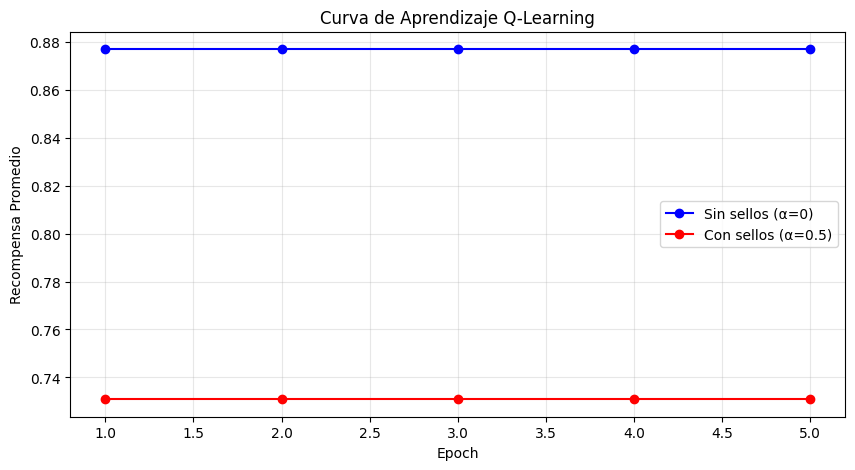

In [ ]:
# Curva de aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rewards_no_sellos)+1), rewards_no_sellos, 'b-o', label='Sin sellos (α=0)')
plt.plot(range(1, len(rewards_con_sellos)+1), rewards_con_sellos, 'r-o', label='Con sellos (α=0.5)')
plt.xlabel('Epoch')
plt.ylabel('Recompensa Promedio')
plt.title('Curva de Aprendizaje Q-Learning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Métricas de Evaluación

In [ ]:
def precision_at_k(recommended, relevant, k):
    rec_set = set(recommended[:k])
    rel_set = set(relevant)
    return len(rec_set & rel_set) / k

def recall_at_k(recommended, relevant, k):
    rec_set = set(recommended[:k])
    rel_set = set(relevant)
    if len(rel_set) == 0:
        return 0.0
    return len(rec_set & rel_set) / len(rel_set)

def dcg_at_k(relevances, k):
    relevances = np.asarray(relevances)[:k]
    if relevances.size:
        return np.sum((2**relevances - 1) / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def ndcg_at_k(recommended, relevant, k):
    relevances = [1 if r in relevant else 0 for r in recommended[:k]]
    dcg = dcg_at_k(relevances, k)
    ideal = dcg_at_k(sorted(relevances, reverse=True), k)
    if ideal == 0:
        return 0.0
    return dcg / ideal

def average_precision(recommended, relevant, k):
    hits = 0
    sum_prec = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            sum_prec += hits / (i + 1)
    if len(relevant) == 0:
        return 0.0
    return sum_prec / min(len(relevant), k)

def sellos_at_k(recommended_recipes, recipe_sellos_dict, k):
    """S@K: promedio de sellos por receta en top-K (menor = más saludable)"""
    sellos = [recipe_sellos_dict.get(r, 0) for r in recommended_recipes[:k]]
    return np.mean(sellos) if sellos else 0.0

def sello_free_at_k(recommended_recipes, recipe_sellos_dict, k):
    """SS@K: porcentaje de recetas sin sellos en top-K (mayor = más saludable)"""
    sellos = [recipe_sellos_dict.get(r, 0) for r in recommended_recipes[:k]]
    if not sellos:
        return 0.0
    return np.mean([1 if s == 0 else 0 for s in sellos])

print("Métricas de evaluación definidas: Precision@K, Recall@K, nDCG@K, MAP, S@K, SS@K")

Métricas de evaluación definidas: Precision@K, Recall@K, nDCG@K, MAP, S@K, SS@K


## 7. Evaluación de los Agentes

In [ ]:
def evaluate_agent(agent, user_interactions_train, user_interactions_test,
                   recipe_to_action, action_to_recipe, recipe_sellos, k=10):
    """
    Evalúa el agente generando top-K recomendaciones para cada usuario de test.
    """
    metrics = {
        'precision': [], 'recall': [], 'ndcg': [], 'map': [],
        's_at_k': [], 'ss_at_k': []
    }

    test_users = list(user_interactions_test.keys())

    for user_id in tqdm(test_users, desc="Evaluando usuarios"):
        train_history = user_interactions_train.get(user_id, [])
        test_items = user_interactions_test[user_id]

        state = get_user_state(train_history, recipe_sellos)

        # Excluir recetas ya vistas
        seen_actions = set()
        for rid, _ in train_history:
            if rid in recipe_to_action:
                seen_actions.add(recipe_to_action[rid])

        # Obtener top-K recomendaciones
        top_k_actions = agent.get_top_k(state, k=k, exclude_actions=seen_actions)
        recommended_recipes = [action_to_recipe[a] for a in top_k_actions]

        # Items relevantes del test (rating >= 4)
        relevant = set(rid for rid, rating in test_items if rating >= 4)

        # Métricas estándar
        metrics['precision'].append(precision_at_k(recommended_recipes, relevant, k))
        metrics['recall'].append(recall_at_k(recommended_recipes, relevant, k))
        metrics['ndcg'].append(ndcg_at_k(recommended_recipes, relevant, k))
        metrics['map'].append(average_precision(recommended_recipes, relevant, k))

        # Métricas de salud
        metrics['s_at_k'].append(sellos_at_k(recommended_recipes, recipe_sellos, k))
        metrics['ss_at_k'].append(sello_free_at_k(recommended_recipes, recipe_sellos, k))

    results = {metric: np.mean(values) for metric, values in metrics.items()}
    return results

In [ ]:
K = 10

print("Evaluando Q-Learning SIN sellos...")
results_no_sellos = evaluate_agent(
    agent_no_sellos, user_interactions_train, user_interactions_test,
    recipe_to_action, action_to_recipe, recipe_sellos, k=K
)

print("\nEvaluando Q-Learning CON sellos (α=0.5)...")
results_con_sellos = evaluate_agent(
    agent_con_sellos, user_interactions_train, user_interactions_test,
    recipe_to_action, action_to_recipe, recipe_sellos, k=K
)

Evaluando Q-Learning SIN sellos...


Evaluando usuarios:   0%|          | 0/17328 [00:00<?, ?it/s]


Evaluando Q-Learning CON sellos (α=0.5)...


Evaluando usuarios:   0%|          | 0/17328 [00:00<?, ?it/s]

In [ ]:
results_df = pd.DataFrame({
    'Métrica': [
        f'Precision@{K}', f'Recall@{K}', f'nDCG@{K}', 'MAP',
        f'S@{K} (avg sellos)', f'SS@{K} (% sin sellos)'
    ],
    'Q-Learning (sin sellos)': [
        round(results_no_sellos['precision'], 4),
        round(results_no_sellos['recall'], 4),
        round(results_no_sellos['ndcg'], 4),
        round(results_no_sellos['map'], 4),
        round(results_no_sellos['s_at_k'], 4),
        round(results_no_sellos['ss_at_k'], 4),
    ],
    'Q-Learning (con sellos, α=0.5)': [
        round(results_con_sellos['precision'], 4),
        round(results_con_sellos['recall'], 4),
        round(results_con_sellos['ndcg'], 4),
        round(results_con_sellos['map'], 4),
        round(results_con_sellos['s_at_k'], 4),
        round(results_con_sellos['ss_at_k'], 4),
    ]
})

display(results_df)

,Métrica,Q-Learning (sin sellos),"Q-Learning (con sellos, α=0.5)"
0,Precision@10,0.0062,0.0055
1,Recall@10,0.0617,0.0553
2,nDCG@10,0.0315,0.0279
3,MAP,0.0225,0.0197
4,S@10 (avg sellos),1.2856,0.7661
5,SS@10 (% sin sellos),0.2588,0.4746


## 8. Análisis de Sensibilidad del Parámetro α

In [ ]:
alphas = [0.0, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
sensitivity_results = []

for alpha in alphas:
    print(f"\n--- Entrenando con α={alpha} ---")
    agent = QLearningAgent(num_actions=NUM_ACTIONS)
    train_agent(agent, user_interactions_train, recipe_to_action,
                recipe_sellos, alpha=alpha, num_epochs=5)

    results = evaluate_agent(
        agent, user_interactions_train, user_interactions_test,
        recipe_to_action, action_to_recipe, recipe_sellos, k=K
    )
    results['alpha'] = alpha
    sensitivity_results.append(results)

sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df)


--- Entrenando con α=0.0 ---
Epoch 1/5 - Avg Reward: 0.8770 - Epsilon: 0.9950
Epoch 2/5 - Avg Reward: 0.8770 - Epsilon: 0.9900
Epoch 3/5 - Avg Reward: 0.8770 - Epsilon: 0.9851
Epoch 4/5 - Avg Reward: 0.8770 - Epsilon: 0.9801
Epoch 5/5 - Avg Reward: 0.8770 - Epsilon: 0.9752


Evaluando usuarios:   0%|          | 0/17328 [00:00<?, ?it/s]


--- Entrenando con α=0.1 ---
Epoch 1/5 - Avg Reward: 0.8477 - Epsilon: 0.9950
Epoch 2/5 - Avg Reward: 0.8477 - Epsilon: 0.9900
Epoch 3/5 - Avg Reward: 0.8477 - Epsilon: 0.9851
Epoch 4/5 - Avg Reward: 0.8477 - Epsilon: 0.9801
Epoch 5/5 - Avg Reward: 0.8477 - Epsilon: 0.9752


Evaluando usuarios:   0%|          | 0/17328 [00:00<?, ?it/s]


--- Entrenando con α=0.2 ---
Epoch 1/5 - Avg Reward: 0.8185 - Epsilon: 0.9950
Epoch 2/5 - Avg Reward: 0.8185 - Epsilon: 0.9900
Epoch 3/5 - Avg Reward: 0.8185 - Epsilon: 0.9851
Epoch 4/5 - Avg Reward: 0.8185 - Epsilon: 0.9801
Epoch 5/5 - Avg Reward: 0.8185 - Epsilon: 0.9752


...


--- Entrenando con α=0.8 ---
Epoch 1/5 - Avg Reward: 0.6433 - Epsilon: 0.9950
Epoch 2/5 - Avg Reward: 0.6433 - Epsilon: 0.9900
Epoch 3/5 - Avg Reward: 0.6433 - Epsilon: 0.9851
Epoch 4/5 - Avg Reward: 0.6433 - Epsilon: 0.9801
Epoch 5/5 - Avg Reward: 0.6433 - Epsilon: 0.9752


Evaluando usuarios:   0%|          | 0/17328 [00:00<?, ?it/s]


--- Entrenando con α=1.0 ---
Epoch 1/5 - Avg Reward: 0.5848 - Epsilon: 0.9950
Epoch 2/5 - Avg Reward: 0.5848 - Epsilon: 0.9900
Epoch 3/5 - Avg Reward: 0.5848 - Epsilon: 0.9851
Epoch 4/5 - Avg Reward: 0.5848 - Epsilon: 0.9801
Epoch 5/5 - Avg Reward: 0.5848 - Epsilon: 0.9752


Evaluando usuarios:   0%|          | 0/17328 [00:00<?, ?it/s]

,precision,recall,ndcg,map,s_at_k,ss_at_k,alpha
0,0.006031,0.060307,0.028101,0.018515,1.157081,0.288539,0.0
1,0.006492,0.064924,0.031385,0.021309,1.010336,0.390414,0.1
2,0.006123,0.061230,0.030172,0.020810,0.730736,0.511738,0.2
3,0.006013,0.060134,0.031004,0.022265,0.668184,0.537714,0.3
4,0.005575,0.055748,0.026510,0.017809,0.500456,0.657681,0.5
5,0.005327,0.053266,0.026405,0.018328,0.431435,0.668363,0.8
6,0.005309,0.053093,0.026442,0.018458,0.279871,0.764451,1.0


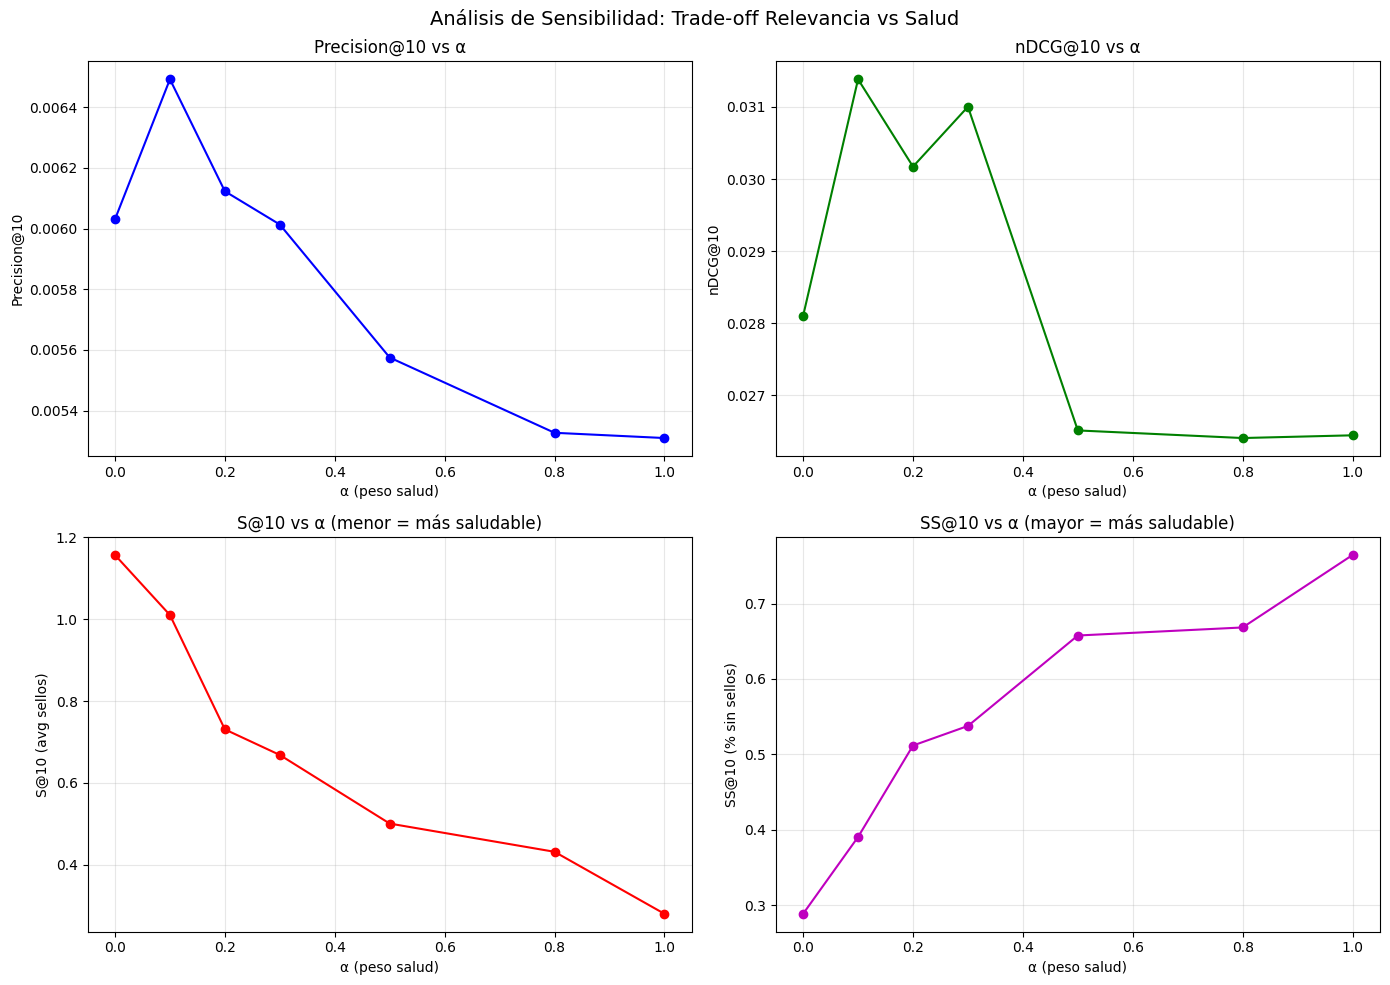

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precision vs alpha
axes[0, 0].plot(sensitivity_df['alpha'], sensitivity_df['precision'], 'b-o')
axes[0, 0].set_xlabel('α (peso salud)')
axes[0, 0].set_ylabel(f'Precision@{K}')
axes[0, 0].set_title(f'Precision@{K} vs α')
axes[0, 0].grid(True, alpha=0.3)

# nDCG vs alpha
axes[0, 1].plot(sensitivity_df['alpha'], sensitivity_df['ndcg'], 'g-o')
axes[0, 1].set_xlabel('α (peso salud)')
axes[0, 1].set_ylabel(f'nDCG@{K}')
axes[0, 1].set_title(f'nDCG@{K} vs α')
axes[0, 1].grid(True, alpha=0.3)

# S@K vs alpha
axes[1, 0].plot(sensitivity_df['alpha'], sensitivity_df['s_at_k'], 'r-o')
axes[1, 0].set_xlabel('α (peso salud)')
axes[1, 0].set_ylabel(f'S@{K} (avg sellos)')
axes[1, 0].set_title(f'S@{K} vs α (menor = más saludable)')
axes[1, 0].grid(True, alpha=0.3)

# SS@K vs alpha
axes[1, 1].plot(sensitivity_df['alpha'], sensitivity_df['ss_at_k'], 'm-o')
axes[1, 1].set_xlabel('α (peso salud)')
axes[1, 1].set_ylabel(f'SS@{K} (% sin sellos)')
axes[1, 1].set_title(f'SS@{K} vs α (mayor = más saludable)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Sensibilidad: Trade-off Relevancia vs Salud', fontsize=14)
plt.tight_layout()
plt.show()

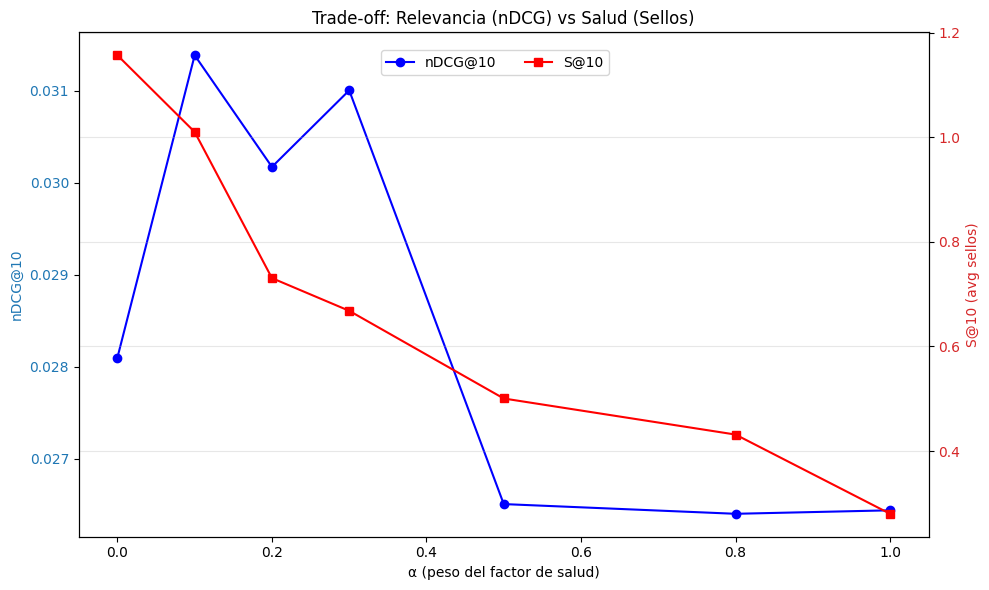

In [ ]:
# Trade-off relevancia vs salud en un solo gráfico
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('α (peso del factor de salud)')
ax1.set_ylabel(f'nDCG@{K}', color=color1)
ax1.plot(sensitivity_df['alpha'], sensitivity_df['ndcg'], 'b-o', label=f'nDCG@{K}')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel(f'S@{K} (avg sellos)', color=color2)
ax2.plot(sensitivity_df['alpha'], sensitivity_df['s_at_k'], 'r-s', label=f'S@{K}')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Trade-off: Relevancia (nDCG) vs Salud (Sellos)')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Tabla Comparativa con Baselines

In [ ]:
# Resultados de baselines (de notebooks anteriores, K=10 para comparabilidad)
# NOTA: Actualizar estos valores con los resultados reales si se re-ejecutan los baselines con K=10
comparison_data = {
    'Modelo': [
        'Content-Based (filtrado, K=10)',
        'Q-Learning sin sellos (α=0)',
        'Q-Learning con sellos (α=0.5)',
    ],
    f'Precision@{K}': [
        0.002,  # Content-Based filtrado
        round(results_no_sellos['precision'], 4),
        round(results_con_sellos['precision'], 4),
    ],
    f'Recall@{K}': [
        0.02,  # Content-Based filtrado
        round(results_no_sellos['recall'], 4),
        round(results_con_sellos['recall'], 4),
    ],
    f'nDCG@{K}': [
        0.02,  # Content-Based filtrado
        round(results_no_sellos['ndcg'], 4),
        round(results_con_sellos['ndcg'], 4),
    ],
    f'S@{K}': [
        '—',  # No calculado para Content-Based
        round(results_no_sellos['s_at_k'], 4),
        round(results_con_sellos['s_at_k'], 4),
    ],
    f'SS@{K}': [
        '—',  # No calculado para Content-Based
        round(results_no_sellos['ss_at_k'], 4),
        round(results_con_sellos['ss_at_k'], 4),
    ],
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Modelo,Precision@10,Recall@10,nDCG@10,S@10,SS@10
0,"Content-Based (filtrado, K=10)",0.0020,0.0200,0.0200,—,—
1,Q-Learning sin sellos (α=0),0.0062,0.0617,0.0315,1.2856,0.2588
2,Q-Learning con sellos (α=0.5),0.0055,0.0553,0.0279,0.7661,0.4746


## 10. Análisis de Recomendaciones

In [ ]:
# Ejemplo: comparar recomendaciones de ambos agentes para un usuario específico
sample_user = list(user_interactions_test.keys())[0]
train_history = user_interactions_train[sample_user]
state = get_user_state(train_history, recipe_sellos)

seen_actions = set()
for rid, _ in train_history:
    if rid in recipe_to_action:
        seen_actions.add(recipe_to_action[rid])

# Recomendaciones sin sellos
top_k_no = agent_no_sellos.get_top_k(state, k=K, exclude_actions=seen_actions)
recs_no = [action_to_recipe[a] for a in top_k_no]

# Recomendaciones con sellos
top_k_con = agent_con_sellos.get_top_k(state, k=K, exclude_actions=seen_actions)
recs_con = [action_to_recipe[a] for a in top_k_con]

print(f"Usuario: {sample_user}")
print(f"Estado: {state}")
print(f"Interacciones de entrenamiento: {len(train_history)}")
print()

def show_recommendations(rec_ids, title):
    print(f"--- {title} ---")
    for i, rid in enumerate(rec_ids):
        name = recipes_filtrado[recipes_filtrado['RecipeId'] == rid]['Name'].iloc[0] if rid in recipes_filtrado['RecipeId'].values else 'N/A'
        sellos = recipe_sellos.get(rid, 0)
        print(f"  {i+1}. {name} (ID: {rid}, Sellos: {sellos})")
    total_sellos = sum(recipe_sellos.get(r, 0) for r in rec_ids)
    sin_sello = sum(1 for r in rec_ids if recipe_sellos.get(r, 0) == 0)
    print(f"  -> S@{K}: {total_sellos/len(rec_ids):.2f} | SS@{K}: {sin_sello/len(rec_ids)*100:.0f}%")
    print()

show_recommendations(recs_no, f"Top-{K} Q-Learning SIN sellos")
show_recommendations(recs_con, f"Top-{K} Q-Learning CON sellos (α=0.5)")

Usuario: 1533
Estado: (2, 0, 1)
Interacciones de entrenamiento: 2

--- Top-10 Q-Learning SIN sellos ---
  1. Bourbon Chicken (ID: 45809, Sellos: 1)
  2. Creamy Cajun Chicken Pasta (ID: 39087, Sellos: 1)
  3. Chicken Lazone (ID: 65768, Sellos: 1)
  4. Jo Mama's World Famous Spaghetti (ID: 22782, Sellos: 1)
  5. Kittencal's Moist Cheddar-Garlic Oven Fried Chicken Breast (ID: 82102, Sellos: 2)
  6. Yes, Virginia There is a Great Meatloaf (ID: 54257, Sellos: 2)
  7. Sesame Chicken (ID: 44321, Sellos: 2)
  8. Crock Pot Whole Chicken (ID: 33671, Sellos: 1)
  9. Spinach Artichoke Dip (ID: 1209, Sellos: 1)
  10. Country White Bread or Dinner Rolls (Bread Machine) (ID: 71373, Sellos: 1)
  -> S@10: 1.30 | SS@10: 0%

--- Top-10 Q-Learning CON sellos (α=0.5) ---
  1. Creamy Cajun Chicken Pasta (ID: 39087, Sellos: 1)
  2. Chicken Lazone (ID: 65768, Sellos: 1)
  3. Kittencal's 5-Minute Cinnamon Flop Brunch Cake (ID: 77397, Sellos: 1)
  4. Jo Mama's World Famous Spaghetti (ID: 22782, Sellos: 1)
  5. 

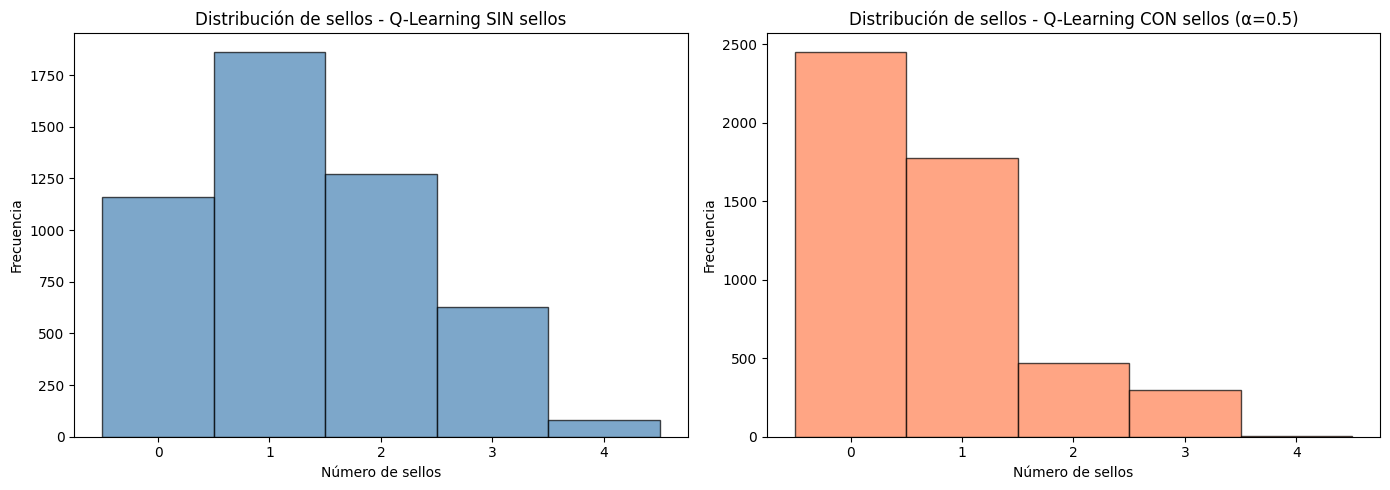

Promedio sellos SIN factor salud: 1.322
Promedio sellos CON factor salud: 0.727


In [ ]:
# Distribución de sellos en recomendaciones de ambos agentes (sobre todos los usuarios de test)
all_recs_no_sellos = []
all_recs_con_sellos = []

for user_id in list(user_interactions_test.keys())[:500]:
    train_hist = user_interactions_train.get(user_id, [])
    st = get_user_state(train_hist, recipe_sellos)

    seen = set()
    for rid, _ in train_hist:
        if rid in recipe_to_action:
            seen.add(recipe_to_action[rid])

    top_no = agent_no_sellos.get_top_k(st, k=K, exclude_actions=seen)
    top_con = agent_con_sellos.get_top_k(st, k=K, exclude_actions=seen)

    for a in top_no:
        all_recs_no_sellos.append(recipe_sellos.get(action_to_recipe[a], 0))
    for a in top_con:
        all_recs_con_sellos.append(recipe_sellos.get(action_to_recipe[a], 0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_recs_no_sellos, bins=range(6), align='left', color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Número de sellos')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de sellos - Q-Learning SIN sellos')
axes[0].set_xticks(range(5))

axes[1].hist(all_recs_con_sellos, bins=range(6), align='left', color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Número de sellos')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de sellos - Q-Learning CON sellos (α=0.5)')
axes[1].set_xticks(range(5))

plt.tight_layout()
plt.show()

print(f"Promedio sellos SIN factor salud: {np.mean(all_recs_no_sellos):.3f}")
print(f"Promedio sellos CON factor salud: {np.mean(all_recs_con_sellos):.3f}")